# Analysis: Mechanistic Variability

We have trained several different Tiny RNN model architectures on a simple reversal task.
What we found is that GRU's trained on the task have varying underlying gating mechanisms.
We sought to minimise this variability by simplifying the architecture, while retaining the performance.


In [2]:
## setup ##
import os
os.chdir('/ceph/behrens/wsilver/reversal/code/')

from NM_TinyRNN.code.measures import analysis
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
from NM_TinyRNN.code.measures import plotting_stats
from NM_TinyRNN.code.measures import performance as perf

from NM_TinyRNN.code.models import submit_jobs # this is the code used to train models!

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload

CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# load data
#construct analysis_df and have a look at a subset of data!
info_df = submit_jobs.get_DA_info_df() #code used to submit jobs
all_models_df = analysis.get_analysis_df(info_df, mode='all') #code to aggregate all paths and some data
performance_df = perf.get_performance_df(all_models_df) #code to recompute evaluations and aggregate
best_model_df = perf.select_best_outer(performance_df) #

print("Available model types (model_type2):")
print(all_models_df.model_type2.unique())

Loaded analysis paths from cache: NM_TinyRNN/data/analysis/analysis_df_final.htsv
Loaded performance dataframe from cache: NM_TinyRNN/data/analysis/performance_df_final.htsv
Available model types (model_type2):
['GRU+BC' 'GRU+BC-DB' 'GRU' 'monoGRU+BC' 'monoGRU+BC-DB']


## Subject-level examples

To get an idea of what's going on at the level of hidden states across training seeds, let's look at some single-subject examples.

In [4]:
best_model_df.subject_id.unique()

array(['WS01', 'WS02', 'WS05', 'WS08', 'WS09', 'WS10', 'WS13', 'WS14',
       'WS16', 'WS20', 'WS22'], dtype=object)

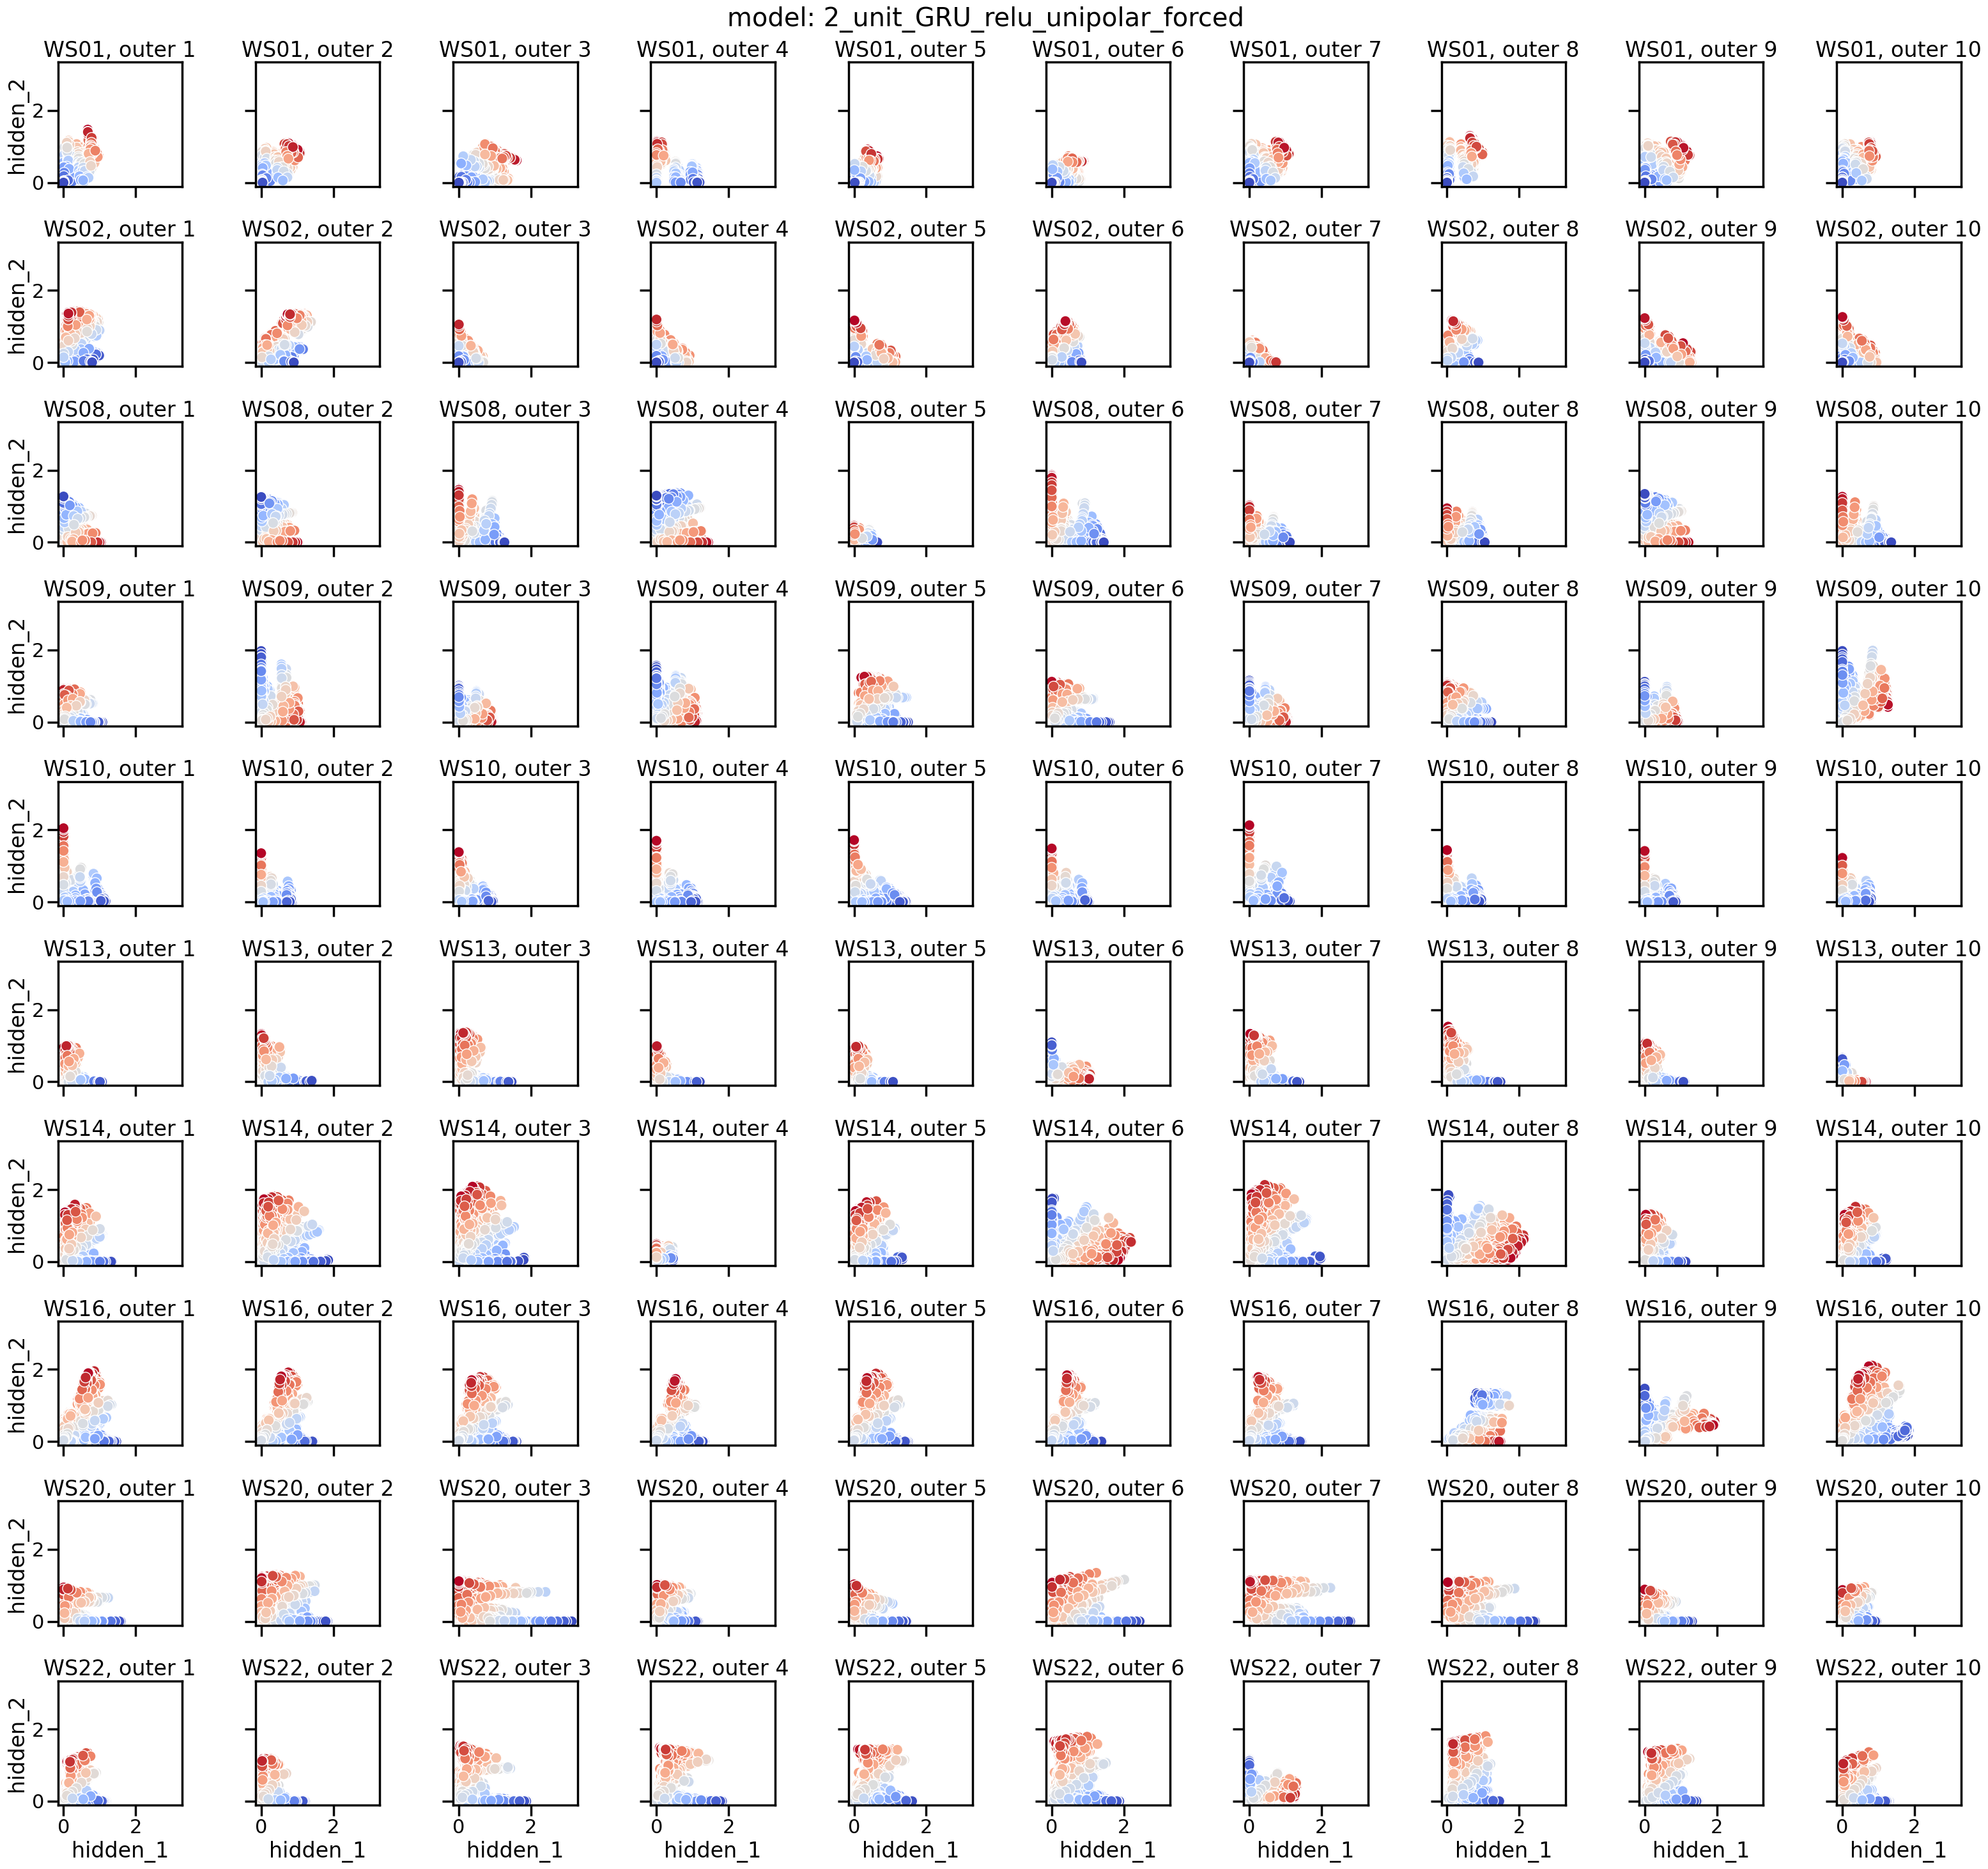

In [26]:
## Have a look at the mechanisms across folds !
subject_list = ['WS01', 'WS02', 'WS08', 'WS09', 'WS10', 
                'WS13', 'WS14', 'WS16','WS20', 'WS22']
sns.set_context('poster')
subset_df = best_model_df.query('model_id=="2_unit_GRU_relu_unipolar_forced"')
subset_df = subset_df[subset_df.subject_id.isin(subject_list)]
subset_df = subset_df.sort_values(by=['subject_id','outer_loop_n'])

fig, ax = plt.subplots(len(subject_list),10,figsize=(32,len(subject_list)*3), sharex=True, sharey=True)
axes = ax.flatten()
for i,each_row in enumerate(subset_df.itertuples()):
    trials_data = analysis.load_data(each_row.trials_data_path)
    sns.scatterplot(trials_data, x= 'hidden_1',y='hidden_2',
                    hue = 'logit_value', palette='coolwarm',
                    legend = False, ax = axes[i])
    axes[i].set_title(f'{each_row.subject_id}, outer {each_row.outer_loop_n}')
    axes[i].axis('square')
fig.suptitle(f'model: {each_row.model_id}')
fig.tight_layout()

<Axes: xlabel='logit_past', ylabel='logit_change'>

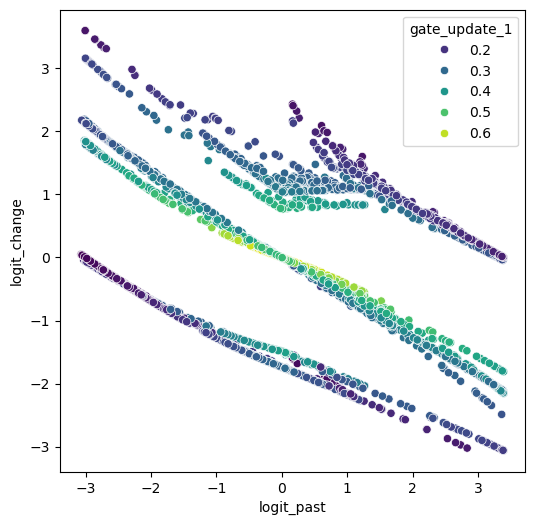

In [21]:
# single subject example
subject_id="WS16"
model_id = "2_unit_monoGRU_relu_unipolar_forced_ndb"
outer_loop_n = 10
select_df = best_model_df.query(f"subject_id=='{subject_id}' and model_id=='{model_id}' and outer_loop_n=={outer_loop_n}")

fig, ax = plt.subplots(1,1,figsize=(6,6))
trials_data = analysis.load_data(select_df.trials_data_path.iloc[0])
sns.scatterplot(trials_data, x= 'logit_past',y='logit_change', hue='gate_update_1',palette='viridis')

In [18]:
(trials_data['logit_value']-trials_data['logit_past']) == trials_data['logit_change']

0       False
1       False
2       False
3       False
4       False
        ...  
4243    False
4244    False
4245    False
4246    False
4247    False
Length: 4248, dtype: bool

In [11]:
trials_data

,hidden_1,hidden_2,gate_update_1,forced_choice,choice,outcome,good_poke,session_folder_name,session_trial_idx,sequence_block_idx,block_trial_idx,trial_type,logit_value,logit_past,logit_change,prob_A,prob_B,split
0,0.395711,0.796407,0.204392,1,0,1,1,WS16/2025-05-01-164959,0,0.0,0.0,"A1,R=1",1.229414,NaN,NaN,0.773716,0.226284,train
1,0.060755,1.022968,0.153534,0,0,1,1,WS16/2025-05-01-164959,1,0.0,1.0,"A1,R=1",2.831740,1.229414,1.602326,0.944367,0.055633,train
2,0.018617,0.377732,0.306427,0,0,0,1,WS16/2025-05-01-164959,2,0.0,2.0,"A1,R=0",1.056307,2.831740,-1.775433,0.741984,0.258016,train
3,0.008282,0.168035,0.444851,0,0,0,1,WS16/2025-05-01-164959,3,0.0,3.0,"A1,R=0",0.469899,1.056307,-0.586408,0.615360,0.384640,train
4,0.503030,0.065036,0.387037,1,1,1,1,WS16/2025-05-01-164959,4,0.0,4.0,"A2,R=1",-1.217089,0.469899,-1.686989,0.228449,0.771551,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,0.016780,0.025657,0.511137,0,0,0,1,WS16/2025-05-14-170159,457,123.0,457.0,"A1,R=0",0.028324,0.055413,-0.027089,0.507080,0.492920,eval
4244,0.007935,0.012133,0.472898,0,1,0,1,WS16/2025-05-14-170159,458,123.0,458.0,"A2,R=0",0.013394,0.028324,-0.014929,0.503348,0.496652,eval
4245,0.005139,0.007857,0.647579,1,0,0,1,WS16/2025-05-14-170159,459,123.0,459.0,"A1,R=0",0.008674,0.013394,-0.004720,0.502168,0.497832,eval
4246,0.002709,0.004142,0.527211,0,0,0,1,WS16/2025-05-14-170159,460,123.0,460.0,"A1,R=0",0.004573,0.008674,-0.004101,0.501143,0.498857,eval


## Similarities in activations

For each subject, we select the 10 best models, then run each model on data from all subjects. 
We then compute the pearson correlation between logits, hidden states, and update gate activations. 

We show that both within subjects (across folds) and across subjects, a standard GRU will have similar logits but large variability in hidden states and gate activations. We reduced this variance by simplifying the gated architecture, adding biological constraints, and removing decoder bias terms.



In [24]:
# Across all gating architectures - gating variability.
## Figure 2: variability in GRU model mechanisms.
model_list = ['GRU','monoGRU+BC-DB']
subject_list = best_model_df.subject_id.unique()
USE_BEST_MODELS = True

source_df = best_model_df if USE_BEST_MODELS else all_models_df
select_models = source_df.query('hidden_size==2 and input_encoding == "unipolar"').copy()
select_models = select_models[select_models.model_type2.isin(model_list)]
select_models = select_models[select_models.subject_id.isin(subject_list)]
select_models['model_id'] = select_models.model_type2
#print(select_models)
sim_df = mech_var.compute_similarities(select_models, similarity_measure='pearson', use_cache = True)

sim_df

Loaded similarity dataframe from cache: NM_TinyRNN/data/analysis/mechanistic_variability_pearson_similarities_v2.htsv


,model_id,subject_A,model_A_outer_n,model_A_inner_n,subject_B,model_B_outer_n,model_B_inner_n,trial_subject,component,similarity,similarity_measure,within_subject
0,GRU,WS01,1,6,WS01,2,6,WS01,hidden,0.971491,pearson,True
1,GRU,WS01,1,6,WS01,2,6,WS01,gate_update,0.972386,pearson,True
2,GRU,WS01,1,6,WS01,2,6,WS01,gate_reset,0.623861,pearson,True
3,GRU,WS01,1,6,WS01,2,6,WS01,logit_value,0.988065,pearson,True
4,GRU,WS01,1,6,WS01,3,6,WS01,hidden,0.932006,pearson,True
...,...,...,...,...,...,...,...,...,...,...,...,...
107905,monoGRU+BC-DB,WS22,8,3,WS22,10,4,WS22,gate_update,0.944895,pearson,True
107906,monoGRU+BC-DB,WS22,8,3,WS22,10,4,WS22,logit_value,0.996874,pearson,True
107907,monoGRU+BC-DB,WS22,9,2,WS22,10,4,WS22,hidden,0.967017,pearson,True
107908,monoGRU+BC-DB,WS22,9,2,WS22,10,4,WS22,gate_update,0.962808,pearson,True


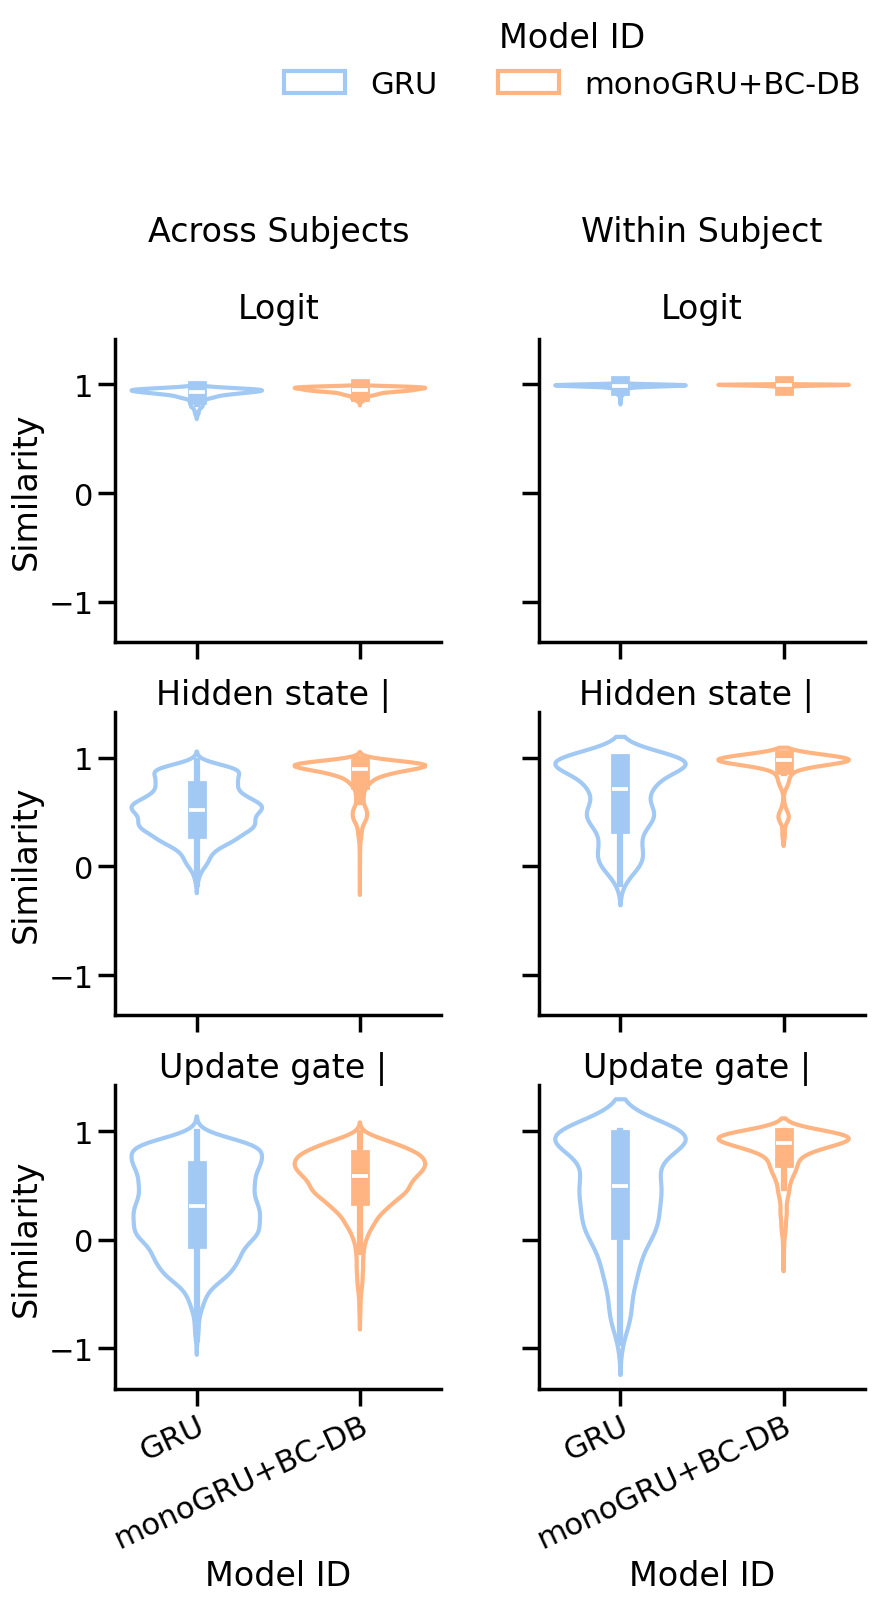

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map component values to clean titles
component_map = {
    'logit_value': 'Logit',
    'hidden': 'Hidden state',
    'gate_update': 'Update gate',
}
model_list = ['GRU','monoGRU+BC-DB']
plot_df = sim_df[sim_df.model_id.isin(model_list)].copy()
plot_df = plot_df.query('component!="reset_gate"')
plot_df['component_clean'] = plot_df['component'].map(component_map)

sns.set_context('poster')

g = sns.catplot(
    data=plot_df,
    row='component_clean',
    col='within_subject',
    y='similarity',
    x='model_id',
    hue='model_id',
    palette='pastel',
    row_order=['Logit', 'Hidden state', 'Update gate'],
    col_order=[False, True],
    kind='violin',
    fill=False,
    aspect=1.0,
    legend=True,
)

# 1. Clear default facet titles and set clean row titles
g.set_titles(col_template='', row_template='{row_name}')

# 2. Add titles over the top row for subject condition
g.axes[0, 0].set_title('Across Subjects\n\nLogit', pad=15)
g.axes[0, 1].set_title('Within Subject\n\nLogit', pad=15)

# 3. Set explicit axis titles (retaining Model ID on the x-axis)
g.set_axis_labels(x_var='Model ID', y_var='Similarity')

# 4. Rotate and align tick labels on every subplot
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right', rotation_mode='anchor')

# 5. Position and adjust the top legend
sns.move_legend(
    g,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(plot_df['model_id'].unique()),
    title='Model ID',
    frameon=False,
)

# Adjust layout spacing to accommodate labels and legend
plt.subplots_adjust(top=0.85, bottom=0.15)
plt.show()

<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2758992/907496002.py:59: SyntaxWarning: invalid escape sequence '\D'
  axes[0, column].set(xlabel = 'logit, $L_t$', ylabel = 'Logit change, $\Delta L_t$')


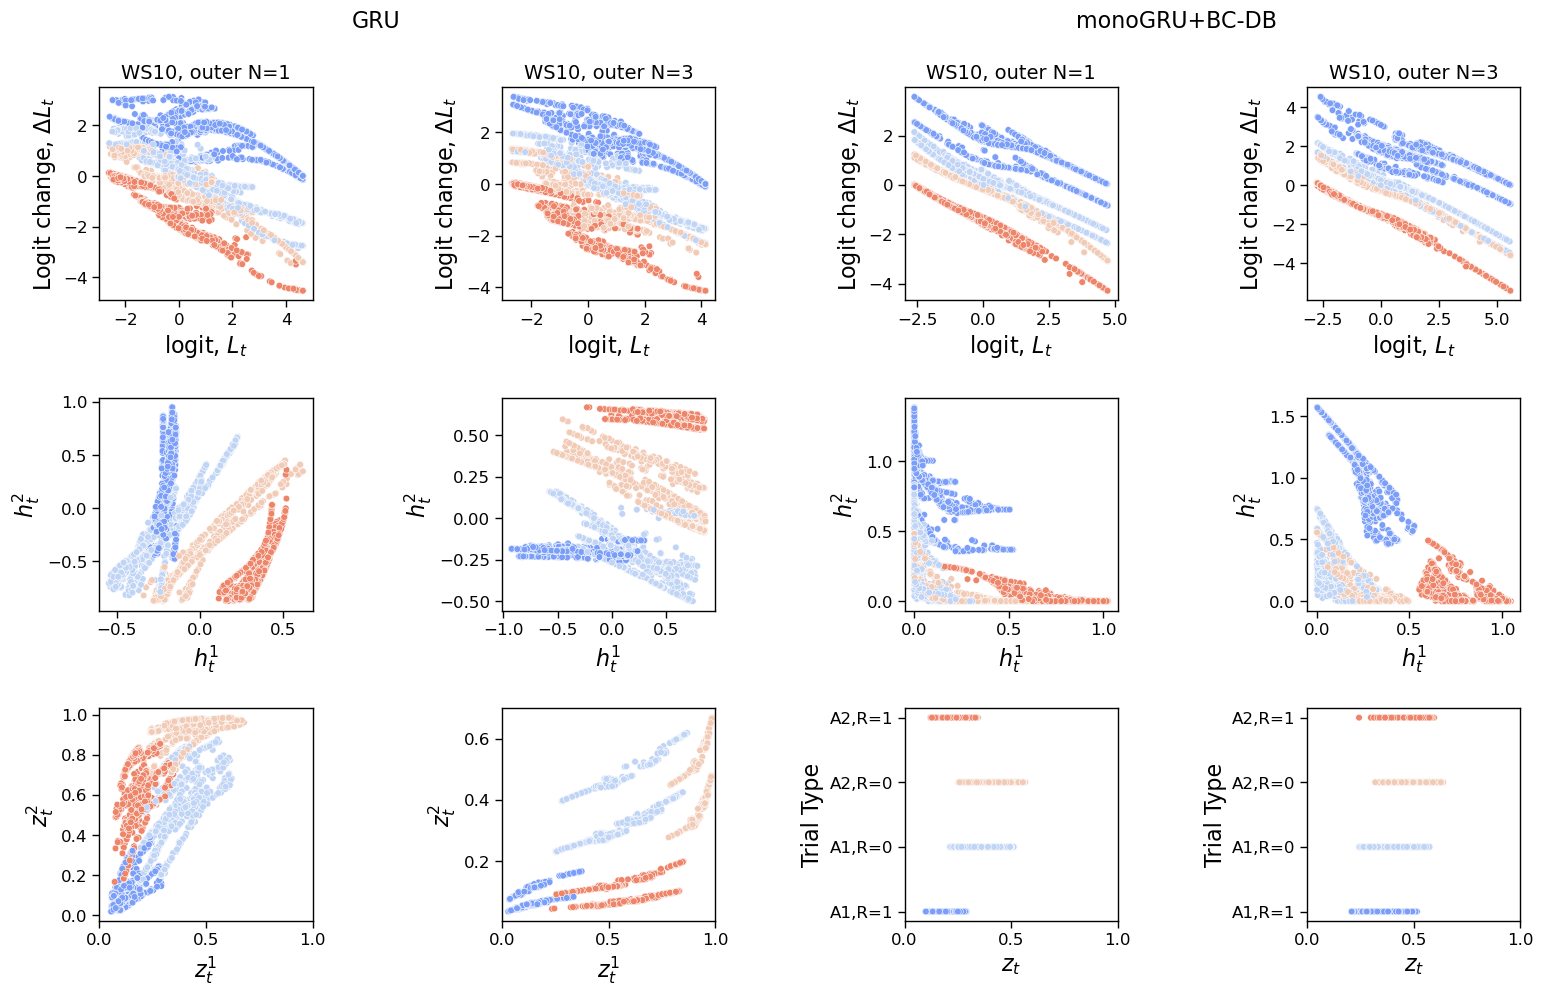

In [27]:
# Compare best models from matched outer folds across the two architectures
subject_id = "WS10"

# Use a low-similarity within-subject GRU pair as the example.
gru_sim_df = sim_df.query(
    'model_id=="GRU" and component=="hidden" and '
    '0.0 < similarity < 0.5'
)
subject_specific = gru_sim_df.query(
    f'subject_A=="{subject_id}" and subject_B=="{subject_id}" and '
    f'trial_subject=="{subject_id}"'
)
example = subject_specific.iloc[0]
outer_folds = [example.model_A_outer_n, example.model_B_outer_n]

# Select each architecture's best inner-fold model for the same outer folds.
selected_models = best_model_df.query(
    f'subject_id=="{subject_id}" and hidden_size==2 and '
    'input_encoding=="unipolar" and '
    'model_type2 in ["GRU", "monoGRU+BC-DB"]'
).copy()
selected_models = selected_models[
    selected_models.outer_loop_n.isin(outer_folds)
].sort_values(["model_type2", "outer_loop_n"])

# Keep the GRU pair first, followed by the matched monoGRU pair.
plot_models = []
for model_type in ["GRU", "monoGRU+BC-DB"]:
    model_rows = selected_models[
        selected_models.model_type2 == model_type
    ].sort_values("outer_loop_n")
    plot_models.extend(model_rows.itertuples())

assert len(plot_models) == 4, (
    "Expected two best outer-fold models for each architecture."
)

sns.set_context("paper")
cp = sns.color_palette("coolwarm", n_colors=4)
color_map = {
    "A1,R=0": cp[1], "A1,R=1": cp[0],
    "A2,R=0": cp[2], "A2,R=1": cp[3],
}

fig, axes = plt.subplots(3, 4, figsize=(16, 10), squeeze=False)
for column, each_model in enumerate(plot_models):
    trials_data = analysis.load_data(each_model.trials_data_path)
    column_title = (
        f"{each_model.subject_id}, "
        f"outer N={each_model.outer_loop_n}"
    )

    sns.scatterplot(
        data=trials_data,
        x="logit_past", y="logit_change",
        hue="trial_type", palette=color_map,
        legend=False, ax=axes[0, column],
    )
    axes[0, column].set(xlabel = 'logit, $L_t$', ylabel = 'Logit change, $\Delta L_t$')

    sns.scatterplot(
        data=trials_data,
        x="hidden_1", y="hidden_2",
        hue="trial_type", palette=color_map,
        legend=False, ax=axes[1, column],
    )
    axes[1,column].set(xlabel = '$h^1_t$', ylabel = '$h^2_t$')

   
    if 'gate_update_2' in trials_data.columns:
        gate_y = 'gate_update_2'
        axes[2,column].set(xlabel = '$z^1_t$', ylabel = '$z^2_t$')
    else:
        gate_y = 'trial_type'
        axes[2,column].set(xlabel = '$z_t$', ylabel = 'Trial Type')
          
    sns.scatterplot(
        data=trials_data,
        x="gate_update_1", y=gate_y,
        hue="trial_type", palette=color_map,
        legend=False, ax=axes[2, column],
    )
    
    for row in range(3):
        axes[row, column].set_box_aspect(1)
        axes[row, column].tick_params(labelsize=12)
        axes[row, column].xaxis.label.set_size(16)
        axes[row, column].yaxis.label.set_size(16)

    axes[0, column].set_title(column_title, fontsize=14)
    axes[2, column].set_xlim(0, 1)
    axes[2, column].set_xticks([0, 0.5, 1])

fig.text(0.25, 0.99, "GRU", ha="center", va="top", fontsize=16)
fig.text(0.75, 0.99, "monoGRU+BC-DB", ha="center", va="top", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.95), w_pad=2.5, h_pad=2.5)
plt.show()

## Similarities in weights

In [38]:

## Figure 2: variability in GRU model mechanisms.
model_list = best_model_df.model_type2.unique()# ['GRU','monoGRU+BC-DB']
subject_list = ['WS01', 'WS02', 'WS05', 'WS08', 'WS09', 'WS10', 
                'WS13', 'WS14', 'WS16', 'WS22']
select_models = best_model_df.query('hidden_size==2 and input_encoding == "unipolar" ')
select_models = select_models[select_models.model_type2.isin(model_list)]
select_models = select_models[select_models.subject_id.isin(subject_list)]
select_models['model_id'] = select_models.model_type2

df = mech_var.compute_weight_similarities(select_models, 
                                          similarity_measure='cosine')

df

,model_id,subject_A,outer_loop_n_A,inner_loop_idx_A,subject_B,outer_loop_n_B,inner_loop_idx_B,within_subject,similarity,sim_original,similarity_measure
0,GRU,WS01,1,6,WS01,2,6,True,0.843990,0.843990,cosine
1,GRU,WS01,1,6,WS01,3,6,True,0.346786,0.346786,cosine
2,GRU,WS01,1,6,WS01,4,6,True,0.921098,0.921098,cosine
3,GRU,WS01,1,6,WS01,5,6,True,0.934858,0.934858,cosine
4,GRU,WS01,1,6,WS01,6,6,True,0.834753,0.834753,cosine
...,...,...,...,...,...,...,...,...,...,...,...
24745,monoGRU+BC-DB,WS22,7,4,WS22,9,2,True,0.607065,0.607065,cosine
24746,monoGRU+BC-DB,WS22,7,4,WS22,10,4,True,0.665049,0.665049,cosine
24747,monoGRU+BC-DB,WS22,8,3,WS22,9,2,True,0.941644,0.941644,cosine
24748,monoGRU+BC-DB,WS22,8,3,WS22,10,4,True,0.966671,0.966671,cosine


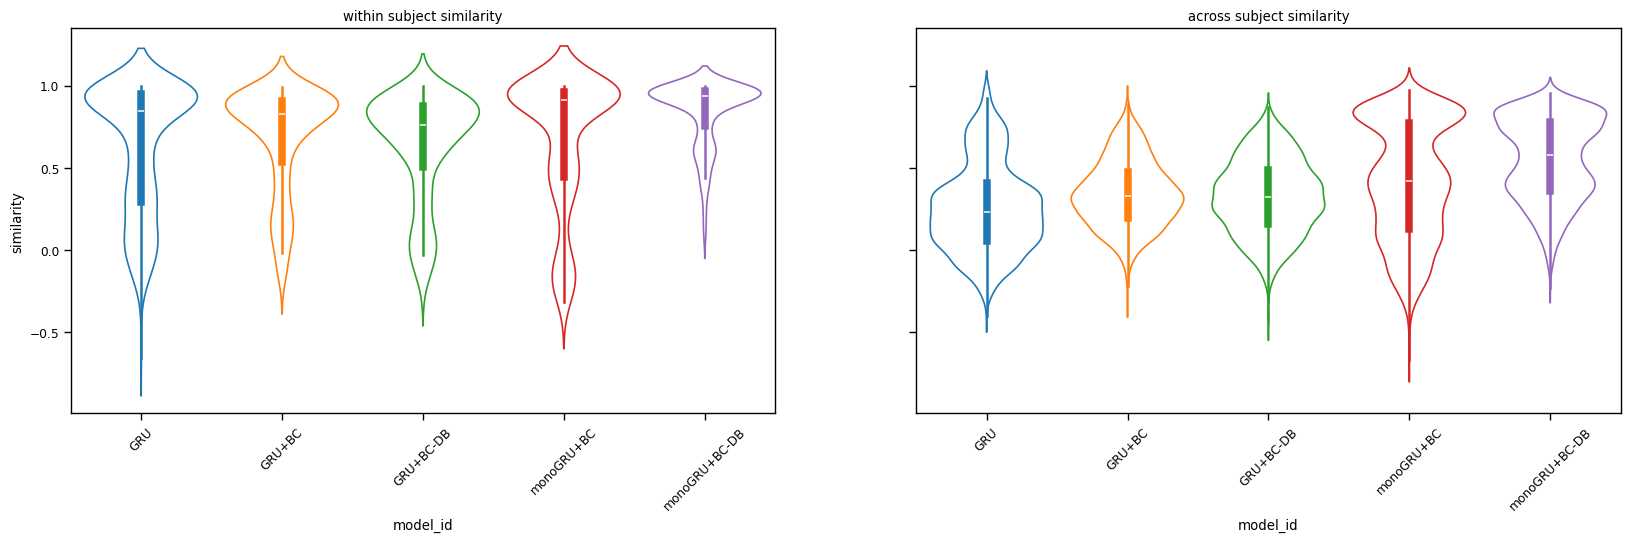

In [39]:
fig, ax = plt.subplots(1,2, figsize = (20,5), sharey=True)
sns.violinplot(df.query('within_subject == True'), 
               x= 'model_id', y = 'similarity', 
               hue= 'model_id', fill=False, ax = ax[0])
ax[0].set_title('within subject similarity')
sns.violinplot(df.query('within_subject == False'), 
               x= 'model_id', y = 'similarity', 
               hue= 'model_id', fill=False, ax = ax[1])
ax[1].set_title('across subject similarity')
ax[0].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='x', rotation=45)


In [14]:
example_models = best_model_df.query('model_id=="2_unit_monoGRU_relu_unipolar_forced_ndb" and subject_id=="WS18"')
for each_model in example_models.itertuples():
    trials_data= analysis.load_data(each_model.trials_data_path)
    model = analysis.load_data(each_model.model_pickle_path)
    break

trials_data
for name, p in model.named_parameters():
    print(name,p)

rnn.W_ih Parameter containing:
tensor([[-0.3913, -0.2319],
        [-1.1652,  0.7334],
        [ 1.0996,  0.9367]], requires_grad=True)
rnn.W_hh Parameter containing:
tensor([[ 0.3558, -0.1875],
        [-0.2154,  0.0904]], requires_grad=True)
rnn.W_iz Parameter containing:
tensor([[ 0.7260],
        [ 0.2169],
        [-1.1508]], requires_grad=True)
rnn.W_hz Parameter containing:
tensor([[-0.4848],
        [-1.3845]], requires_grad=True)
rnn.bias_h Parameter containing:
tensor([ 0.1719, -0.6601], requires_grad=True)
rnn.bias_z Parameter containing:
tensor(-0.1911, requires_grad=True)
rnn.hidden_0 Parameter containing:
tensor([ 0.5322, -0.0322], requires_grad=True)
rnn.z_0 Parameter containing:
tensor([0.0017], requires_grad=True)
decoder.weight Parameter containing:
tensor([[ 1.2201, -1.1064],
        [-1.2013,  1.1067]], requires_grad=True)


/tmp/ipykernel_2544384/1390778657.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['context->update gate', 'action->update gate', 'outcome->update gate','hidden->update gate'])


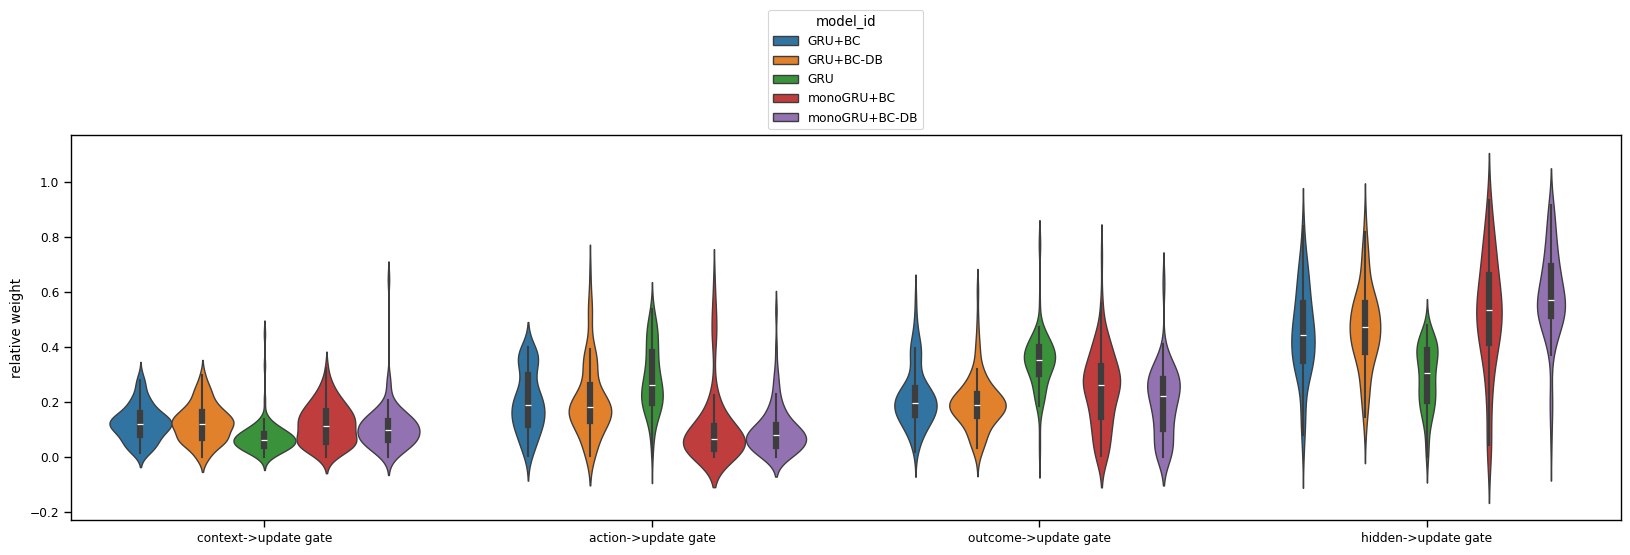

In [37]:
reload(mech_var)
contributions_df = mech_var.parameter_contribution_df(select_models)
update_gate_df = contributions_df[contributions_df.variable.str.contains('update')]
update_gate_df = update_gate_df.dropna()

fig, ax = plt.subplots(figsize=(20, 5))
palette = sns.color_palette('pastel', n_colors=16)  # or 'husl', 'pastel', etc.

sns.violinplot(data=update_gate_df, 
               x='variable', y='value', 
               hue='model_id', 
              dodge=True, ax=ax, )
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, 1))
ax.set_xticklabels(['context->update gate', 'action->update gate', 'outcome->update gate','hidden->update gate'])
handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, ['GRU', 'monoGRU*'], title='', loc='lower center', 
#         bbox_to_anchor=(0.5, 1))
ax.set(xlabel = '',ylabel='relative weight')
plt.show()


In [35]:
params_dict = {k:v.detach().numpy() for k,v in model.named_parameters()}
np.abs(params_dict['rnn.W_hh'])

array([[0.35579574, 0.18745962],
       [0.21537717, 0.09037313]], dtype=float32)